In [1]:
import pandas as pd
import numpy as np

print("Libraries imported!")


Libraries imported!


In [2]:
df = pd.read_csv("data/sales_data.csv")

print("Data loaded successfully!")
print(f"Shape: {df.shape}")


Data loaded successfully!
Shape: (9800, 18)


In [3]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistics:")
print(df.describe())


Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

Statistics:
            Row ID   Postal Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.

In [5]:
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [6]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Cleaned dataframe shape:", df_clean.shape)


Original shape: (9800, 18)
Cleaned dataframe shape: (9800, 18)


In [7]:
print("Duplicate rows:", df_clean.duplicated().sum())


Duplicate rows: 0


In [8]:
df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"],
    dayfirst=True
)

df_clean["Ship Date"] = pd.to_datetime(
    df_clean["Ship Date"],
    dayfirst=True
)

print(df_clean[["Order Date", "Ship Date"]].dtypes)


Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [9]:
df_clean[df_clean["Postal Code"].isnull()]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [10]:
df_clean[
    (df_clean["City"] == "Burlington") &
    (df_clean["State"] == "Vermont") &
    (df_clean["Postal Code"].notna())
]["Postal Code"].unique()


array([], dtype=float64)

In [11]:
df_clean[
    (df_clean["City"] == "Burlington") &
    (df_clean["State"] == "Vermont")
]["Postal Code"].value_counts(dropna=False)


Postal Code
NaN    11
Name: count, dtype: int64

In [12]:
df_clean["Postal Code"] = df_clean["Postal Code"].astype("Int64")

print(df_clean["Postal Code"].dtype)


Int64


In [13]:
print("Shape:", df_clean.shape)
print("\nDuplicates:", df_clean.duplicated().sum())
print("\nMissing values:")
print(df_clean.isnull().sum())
print("\nData types:")
print(df_clean.dtypes)


Shape: (9800, 18)

Duplicates: 0

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Data types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               Int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales               

In [14]:
category_sales = (
    df_clean.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [15]:
category_share = (
    df_clean.groupby("Category")["Sales"]
    .sum()
    .div(df_clean["Sales"].sum())
    .mul(100)
    .round(2)
)

print(category_share)


Category
Furniture          32.22
Office Supplies    31.19
Technology         36.59
Name: Sales, dtype: float64


<Axes: title={'center': 'Total Sales by Category'}, xlabel='Category', ylabel='Sales'>

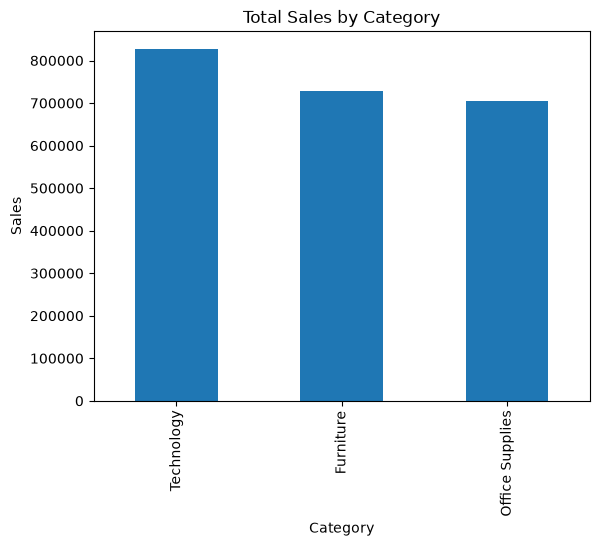

In [16]:
category_sales.plot(
    kind="bar",
    title="Total Sales by Category",
    ylabel="Sales",
    xlabel="Category"
)


In [17]:
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


<Axes: title={'center': 'Top 10 Products by Sales'}, xlabel='Sales', ylabel='Product'>

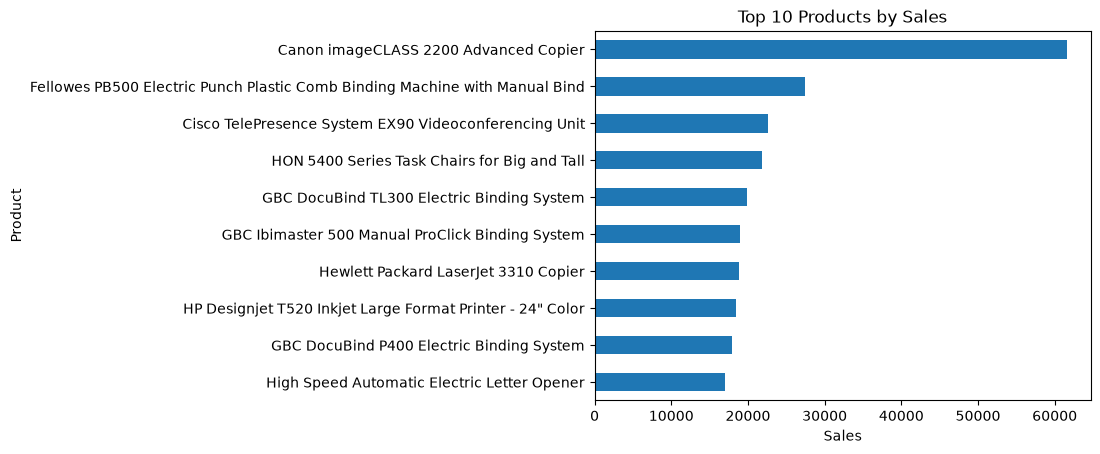

In [18]:
top_products.sort_values().plot(
    kind="barh",
    title="Top 10 Products by Sales",
    xlabel="Sales",
    ylabel="Product"
)


In [19]:
region_sales = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)


Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [20]:
region_share = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .div(df_clean["Sales"].sum())
    .mul(100)
    .round(2)
)

print(region_share)


Region
Central    21.78
East       29.60
South      17.21
West       31.40
Name: Sales, dtype: float64


<Axes: title={'center': 'Total Sales by Region'}, xlabel='Region', ylabel='Sales'>

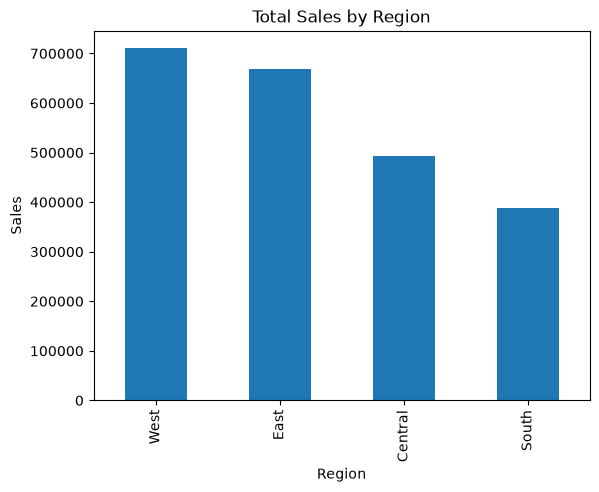

In [21]:
region_sales.plot(
    kind="bar",
    title="Total Sales by Region",
    xlabel="Region",
    ylabel="Sales"
)


In [22]:
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month

print(df_clean[["Order Date", "Year", "Month"]].head())


  Order Date  Year  Month
0 2017-11-08  2017     11
1 2017-11-08  2017     11
2 2017-06-12  2017      6
3 2016-10-11  2016     10
4 2016-10-11  2016     10


In [23]:
monthly_sales = (
    df_clean.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

print(monthly_sales)


    Year  Month        Sales
0   2015      1   14205.7070
1   2015      2    4519.8920
2   2015      3   55205.7970
3   2015      4   27906.8550
4   2015      5   23644.3030
5   2015      6   34322.9356
6   2015      7   33781.5430
7   2015      8   27117.5365
8   2015      9   81623.5268
9   2015     10   31453.3930
10  2015     11   77907.6607
11  2015     12   68167.0585
12  2016      1   18066.9576
13  2016      2   11951.4110
14  2016      3   32339.3184
15  2016      4   34154.4685
16  2016      5   29959.5305
17  2016      6   23599.3740
18  2016      7   28608.2590
19  2016      8   36818.3422
20  2016      9   63133.6060
21  2016     10   31011.7375
22  2016     11   75249.3995
23  2016     12   74543.6012
24  2017      1   18542.4910
25  2017      2   22978.8150
26  2017      3   51165.0590
27  2017      4   38679.7670
28  2017      5   56656.9080
29  2017      6   39724.4860
30  2017      7   38320.7830
31  2017      8   30542.2003
32  2017      9   69193.3909
33  2017     1

In [24]:
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("Date")

print(monthly_sales.head())


   Year  Month      Sales       Date
0  2015      1  14205.707 2015-01-01
1  2015      2   4519.892 2015-02-01
2  2015      3  55205.797 2015-03-01
3  2015      4  27906.855 2015-04-01
4  2015      5  23644.303 2015-05-01


<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Date', ylabel='Sales'>

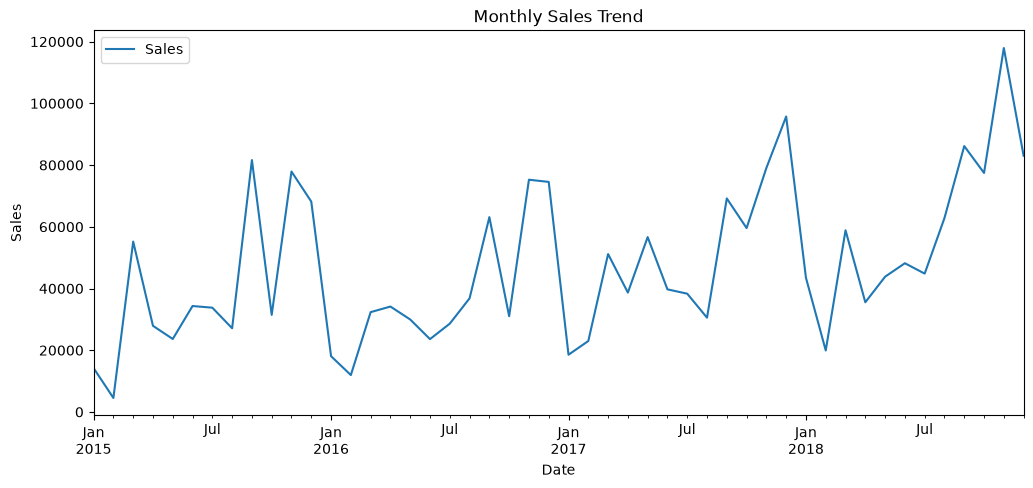

In [25]:
monthly_sales.plot(
    x="Date",
    y="Sales",
    kind="line",
    figsize=(12, 5),
    title="Monthly Sales Trend",
    xlabel="Date",
    ylabel="Sales"
)


In [26]:
top_months = monthly_sales.nlargest(5, "Sales")

print(top_months[["Date", "Sales"]])


         Date        Sales
46 2018-11-01  117938.1550
35 2017-12-01   95739.1210
44 2018-09-01   86152.8880
47 2018-12-01   83030.3888
8  2015-09-01   81623.5268


In [27]:
low_months = monthly_sales.nsmallest(5, "Sales")

print(low_months[["Date", "Sales"]])


         Date       Sales
1  2015-02-01   4519.8920
13 2016-02-01  11951.4110
0  2015-01-01  14205.7070
12 2016-01-01  18066.9576
24 2017-01-01  18542.4910


In [28]:
yearly_sales = (
    df_clean.groupby("Year")["Sales"]
    .sum()
    .sort_index()
)

print(yearly_sales)


Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


<Axes: title={'center': 'Yearly Sales'}, xlabel='Year', ylabel='Sales'>

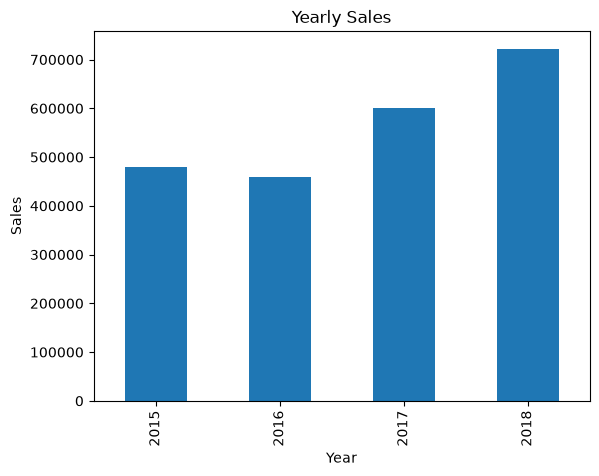

In [29]:
yearly_sales.plot(
    kind="bar",
    title="Yearly Sales",
    xlabel="Year",
    ylabel="Sales"
)


In [30]:
yoy_growth = yearly_sales.pct_change() * 100

print(yoy_growth.round(2))


Year
2015      NaN
2016    -4.26
2017    30.64
2018    20.30
Name: Sales, dtype: float64


In [31]:
yearly_summary = pd.DataFrame({
    "Sales": yearly_sales,
    "YoY Growth %": yoy_growth.round(2)
})

print(yearly_summary)


            Sales  YoY Growth %
Year                           
2015  479856.2081           NaN
2016  459436.0054         -4.26
2017  600192.5500         30.64
2018  722052.0192         20.30


In [32]:
print("=== SALES ANALYSIS SUMMARY ===")

print("\nCategory Sales:")
print(category_sales)

print("\nRegion Sales:")
print(region_sales)

print("\nYearly Sales:")
print(yearly_sales)

print("\nYear-over-Year Growth:")
print(yoy_growth.round(2))

print("\nTop 5 Products:")
print(top_products.head())


=== SALES ANALYSIS SUMMARY ===

Category Sales:
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Region Sales:
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

Yearly Sales:
Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

Year-over-Year Growth:
Year
2015      NaN
2016    -4.26
2017    30.64
2018    20.30
Name: Sales, dtype: float64

Top 5 Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System           

In [33]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


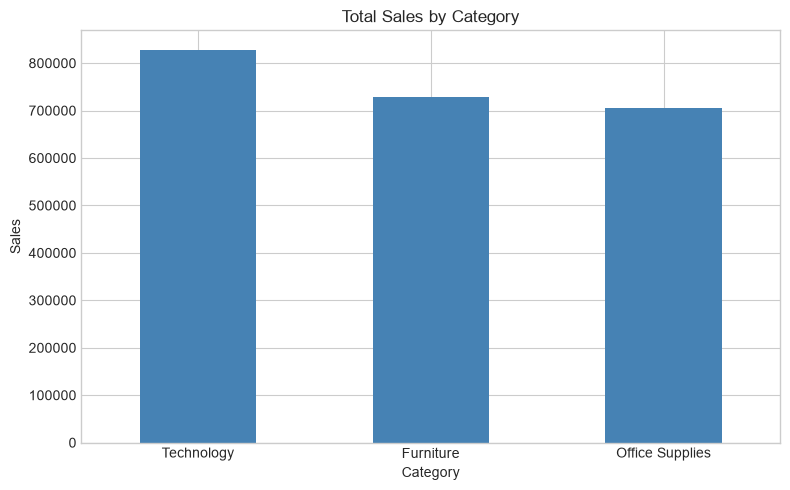

In [34]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar", color="steelblue")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


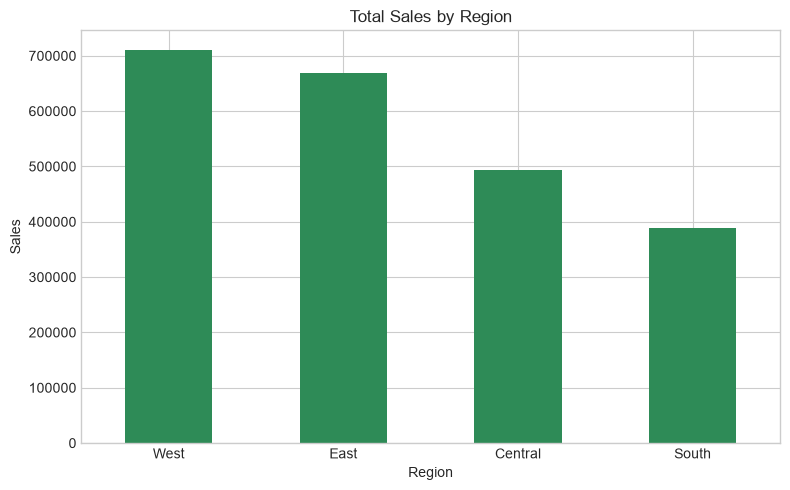

In [35]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar", color="seagreen")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


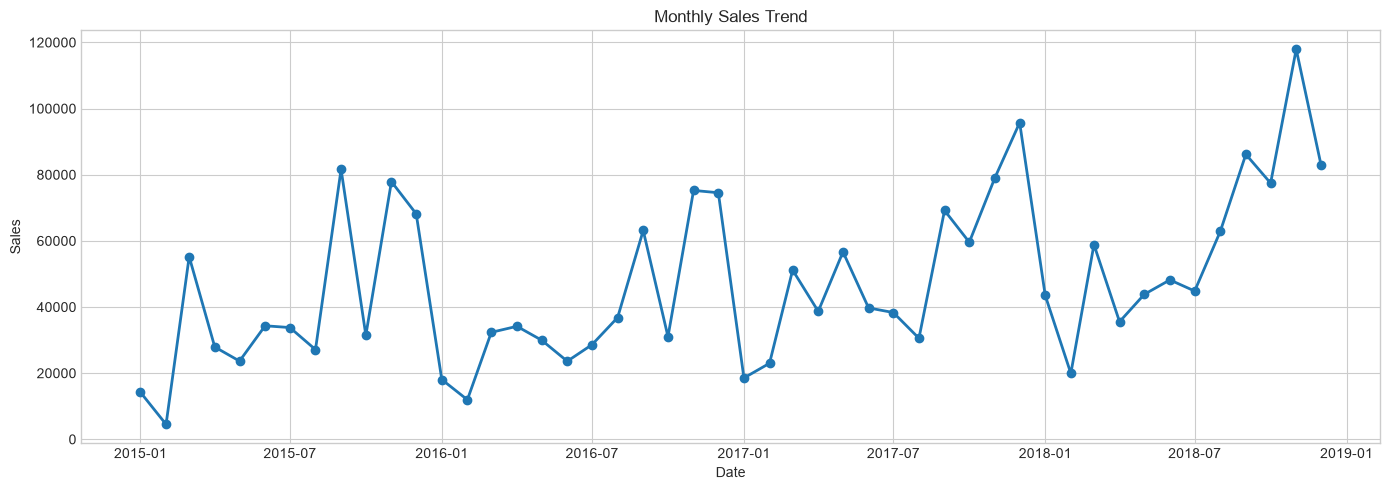

In [36]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()


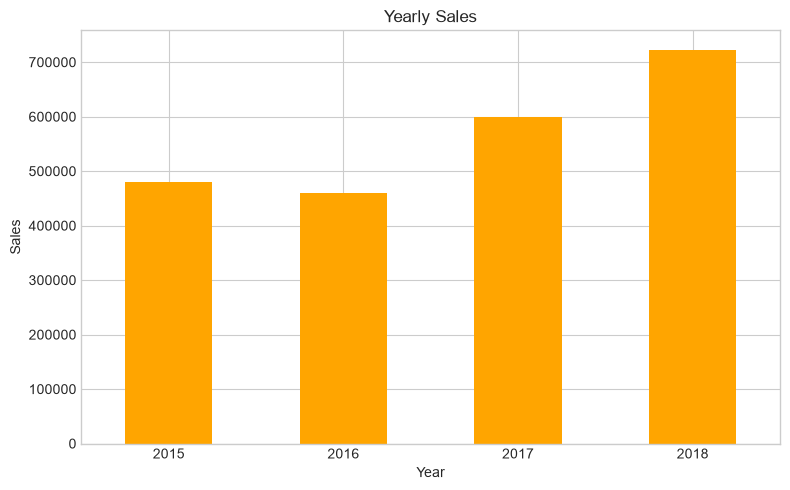

In [37]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind="bar", color="orange")

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


Key Insights
Sales Performance

Total sales were analyzed across 9,800 transactions.

Technology generated the highest total sales among the three categories.

The West region had the highest total sales, followed by the East region.

Sales declined by 4.26% in 2016 compared with 2015.

Sales increased by 30.64% in 2017 compared with 2016.

Sales increased by 20.30% in 2018 compared with 2017.

November 2018 recorded the highest monthly sales in the dataset.

The Canon imageCLASS 2200 Advanced Copier was the top product by total sales.

Eleven Postal Code values were missing. These values were preserved as missing because the dataset contained no known Postal Code for Burlington, Vermont.